### Modèles de regressions avec de la régularisation

In [34]:
import sys
sys.path.append('..')

from utils.fonctions import load_parquet_data, load_pickle
from src.artifacts.data_processing import Nettoyage
from src.artifacts.encoders import LogTransformer

import sklearn
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import numpy as np, pandas as pd

sklearn.set_config(transform_output='pandas')
import matplotlib.pyplot as plt

import category_encoders as ce


def run_nettoyage(data, encoding_pipeline, nettoyage_pipeline: Nettoyage, methode='entropy', downcast_num_cols=True) -> Nettoyage:
    """
    data : pd.DataFrame, dataframe a numeriser
    encoding_pipeline : pipeline de numerisation des variables categorielles
    nettoyage_pipeline : pipeline de nettoyage des variables numeriques (importer depuis src.artifacts.data_processing)
    methode : Methode de nettoyage a utiliser : 'entropy' ou 'target_correlation'
    downcast_num_cols : bool, si True, downcast les colonnes numeriques
    """
    
    def downcast_numeric_cols(data):
        # int32 range = 2**32/2 à gauche et à droite de 0
        for c in data.columns:
            if data[c].dtype == 'int64':
                data[c] = data[c].astype('int32')
            elif data[c].dtype == 'float64':
                data[c] = data[c].astype('float32')
        return data
    
    def numerize(data, encoding_pipeline, downcast_num_cols):
        encoding_pipeline.set_output(transform='pandas')
        data = encoding_pipeline.fit_transform(data)
        if downcast_num_cols:
            print(f"-> downcast des colonnes numeriques (64->32)")
            data = downcast_numeric_cols(data)
        return data
    
    assert isinstance(data, pd.DataFrame), "data doit être un DataFrame"
    if 'arrondissement' not in data.columns: data['arrondissement'] = -1
    data = numerize(data, encoding_pipeline, downcast_num_cols)
    pipeline_ins = nettoyage_pipeline(data)
    if methode == 'entropy':
        pipeline_ins.run(use_entropy_selection=True)
    elif methode == 'target_correlation':
        pipeline_ins.run(use_target_correlation_selection=True)
    else:
        raise ValueError("La méthode doit être 'entropy' ou 'target_correlation'")
    pipeline_ins.df['arrondissement'] = pipeline_ins.df['arrondissement'].astype('int32')
    return pipeline_ins

In [35]:
categ_encoders = load_pickle("../ressources/encoders_fitted/categorical_encoders_v2.pkl")
df_raw = load_parquet_data('../ressources/data/2_intermediary/enedis_ban_ademe_extract_PARIS_2022.parquet')

pipeline = run_nettoyage(df_raw, categ_encoders, Nettoyage, methode='entropy', downcast_num_cols=True)

Loading parquet data from : ../ressources/data/2_intermediary/enedis_ban_ademe_extract_PARIS_2022.parquet..
-> downcast des colonnes numeriques (64->32)
-> Delete cols mano..
-> Delete NaN cols..
Le dataframe contient initialement 251 colonnes et 464576 lignes.
Start processing : columns identification..
Il y a 76 colonnes vides à au moins, 90.0%, 63 colonnes avec une entropie de 0 ou 1 et 13 colonnes inutiles
Start processing : columns deleting ...
Il reste 138 colonnes et 370056 lignes.
-> Start object columns auto casting..
End casting
-> Fill pd.NA for float dtypes..
Done fillnan !
Les colonnes suivantes ont une corrélation supérieure à 0.9 : ['conso_chauffage_depensier_generateur_ndeg1_installation_ndeg1_ademe', 'emission_ges_chauffage_ademe', 'besoin_ecs_ademe', 'cout_ecs_depensier_ademe', 'conso_refroidissement_e_primaire_ademe', 'conso_ecs_e_finale_ademe', 'cout_ecs_energie_ndeg2_ademe', 'cout_chauffage_ademe', 'emission_ges_5_usages_energie_ndeg1_ademe', 'emission_ges_eclairag

In [36]:
df = pipeline.df
df.sort_index(axis=1, inplace=True)
TARGET_COL = "conso_kwh_m2"
# del pipeline

_ = list(filter(lambda c: 'ndeg' not in c, df.columns))

use_cols = [
       # 'annee_construction_ademe', 
       'apports_internes_saison_froid_ademe',
       'apports_solaires_saison_chauffe_ademe',
       'apports_solaires_saison_froid_ademe', 
       'arrondissement',
       'besoin_chauffage_ademe', 
       'besoin_refroidissement_ademe',
       'besoin_refroidissement_depensier_ademe', 
       'categorie_enr_ademe',
       'classe_inertie_batiment_ademe',
       'configuration_installation_chauffage_ndeg1_ademe',
       'configuration_installation_ecs_ademe',
       'conso_5_usages_e_finale_energie_ndeg2_ademe',
       'conso_5_usages_m2_e_finale_ademe',
       'conso_5_usages_par_m2_e_primaire_ademe',
       'conso_auxiliaires_e_primaire_ademe',
       'conso_chauffage_e_primaire_ademe',
       'conso_e_finale_depensier_installation_ecs_ademe',
       'conso_ecs_depensier_e_primaire_ademe',
       'conso_ecs_e_finale_energie_ndeg2_ademe', 
       'conso_kwh_m2',
       'conso_refroidissement_e_finale_ademe',
       'consommation_annuelle_totale_de_l_adresse_mwh_enedis_with_ban',
       # 'coordonnee_cartographique_x_ban_ademe',
       # 'coordonnee_cartographique_y_ban_ademe', 
       'cout_auxiliaires_ademe',
       'cout_chauffage_energie_ndeg2_ademe', 
       'cout_refroidissement_ademe',
       'cout_refroidissement_depensier_ademe',
       'deperditions_baies_vitrees_ademe', 
       'deperditions_planchers_bas_ademe',
       'deperditions_planchers_hauts_ademe', 
       'deperditions_portes_ademe',
       'emission_ges_5_usages_energie_ndeg2_ademe',
       'emission_ges_5_usages_par_m2_ademe',
       'emission_ges_chauffage_energie_ndeg2_ademe',
       'emission_ges_ecs_energie_ndeg2_ademe',
       'emission_ges_refroidissement_ademe',
       'emission_ges_refroidissement_depensier_ademe', 
       'etiquette_dpe_ademe',
       'etiquette_ges_ademe', 
       'hauteur_sous_plafond_ademe',
       # 'lat_enedis_with_ban', 
       # 'lon_enedis_with_ban',
       'methode_application_dpe_ademe', 
       'ndeg_etage_appartement_ademe',
       'nombre_appartement_ademe',
       'nombre_logements_desservis_par_installation_ecs_ademe',
       'nombre_niveau_immeuble_ademe', 
       'nombre_niveau_logement_ademe',
       'periode_construction_ademe', 
       'qualite_isolation_enveloppe_ademe',
       'qualite_isolation_menuiseries_ademe', 
       'qualite_isolation_murs_ademe',
       'qualite_isolation_plancher_bas_ademe',
       'qualite_isolation_plancher_haut_comble_perdu_ademe',
       'qualite_isolation_plancher_haut_toit_terrase_ademe', 
       # 'score_ban_ademe',
       'surface_habitable_immeuble_ademe', 
       'surface_habitable_logement_ademe',
       'type_batiment_ademe',
       # 'type_emetteur_installation_chauffage_ndeg1_ademe',
       'type_enedis_with_ban', 
       'type_energie_generateur_ecs_ndeg1_ademe',
       'type_energie_generateur_ndeg1_installation_ndeg1_ademe',
       'type_energie_ndeg1_ademe', 
       'type_energie_ndeg2_ademe',
       'type_energie_principale_chauffage_ademe',
       'type_energie_principale_ecs_ademe',
       'type_generateur_ecs_ndeg1_ademe',
       'type_generateur_ndeg1_installation_ndeg1_ademe',
       'type_installation_chauffage_ademe',
       'type_installation_chauffage_ndeg1_ademe',
       'type_installation_ecs_ademe',
       'type_installation_ecs_general_ademe', 
       'ubat_w_m2_k_ademe',
       'usage_generateur_ecs_ndeg1_ademe',
       'usage_generateur_ndeg1_installation_ndeg1_ademe',
       # 'version_dpe_ademe', 
       'volume_stockage_generateur_ecs_ndeg1_ademe']

df = df[use_cols]
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
cols_to_scale = list(set(X_train.columns))

def make_model_with_one_hot_encoder_and_log_scaler(model, cols_to_scale, cols_to_encode):
    return Pipeline([
        (
            're_encoding', 
            ColumnTransformer(
                [
                    ('s_scaler', StandardScaler(), cols_to_scale),
                    ('one_hot_encoder', ce.OneHotEncoder(cols=cols_to_encode), cols_to_encode),
                ], 
                remainder='passthrough', 
                verbose_feature_names_out=False)
        ),
        ('model', model)
    ])

def make_model_with_count_encoder_and_standard_scaler(model, cols_to_scale, cols_to_encode):
    return Pipeline([
        (
            're_encoding', 
            ColumnTransformer(
                [
                    ('s_scaler', StandardScaler(), cols_to_scale),
                    ('count_encoder', ce.CountEncoder(cols=cols_to_encode, min_group_size=1_000), cols_to_encode),
                ], 
                remainder='passthrough', 
                verbose_feature_names_out=False)
        ),
        ('model', model)
    ])

def make_model_with_one_hot_encoder_and_standard_scaler(model, cols_to_scale, cols_to_encode):
    return Pipeline([
        (
            're_encoding', 
            ColumnTransformer(
                [
                    ('s_scaler', StandardScaler(), cols_to_scale),
                    ('one_hot_encoder', ce.OneHotEncoder(cols=cols_to_encode), cols_to_encode),
                ], 
                remainder='passthrough', 
                verbose_feature_names_out=False)
        ),
        ('model', model)
    ])


def evaluate_model(model, X_train, X_test, y_train, y_test):
    # fonction pour calculer les métriques
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return model, round(rmse, 3), round(mape, 3), round(r2, 3)

In [38]:
ordinal_features = categ_encoders.named_transformers_['ordinal_encoding'].get_feature_names_out()
label_features = [list(categ_encoders.named_transformers_[c].get_feature_names_out())[0] for c in categ_encoders.named_transformers_.keys() if 'label_encoding_' in c]
categ_features = ordinal_features.tolist() + label_features

to_onehot_encode = list(filter(lambda c: c in categ_features, X.columns))
to_scale = list(filter(lambda c: c not in to_onehot_encode, X.columns))

### Lasso and Ridge Regressions

Lasso (Least Absolute Shrinkage and Selection Operator) and Ridge regression are regularization techniques used to prevent overfitting in linear regression models by adding a penalty term to the loss function.

#### The Alpha Parameter
- The **alpha** parameter controls the strength of the regularization:
    - A higher alpha increases the penalty, leading to more shrinkage of coefficients.
    - A lower alpha reduces the penalty, making the model closer to standard linear regression.
- Choosing the right alpha is crucial and is often done using cross-validation.

In [39]:
# grid for Rid // ridge uses L2 constraint for regularization
ridge_param_grid = {'alpha': np.linspace(0.001, 80, 20)}

# grid for Lasso
lasso_param_grid = {'alpha': np.logspace(0.001, 80, 20)}

#### recherche d'hyperparametres

In [40]:
from concurrent.futures import ThreadPoolExecutor

global opti_alphas
opti_alphas = {}


def make_opti_alphas_with_threads(model, alpha, X_train, y_train, X_test, y_test, name=""):
    model, rmse, mape, r2 = evaluate_model(model, X_train, X_test, y_train, y_test)
    global opti_alphas
    opti_alphas[f"{name}_alpha_{alpha}"] = {
        'name': name,
        'alpha': alpha,
        'model': model,
        'r2': r2,
        'rmse': rmse,
        'mape': mape
    }

# ridge v1
with ThreadPoolExecutor() as pool:
    pool.map(
        lambda alpha: make_opti_alphas_with_threads(
            make_model_with_count_encoder_and_standard_scaler(
                Ridge(alpha=alpha), to_scale, to_onehot_encode
            ),
            alpha,
            X_train,
            y_train,
            X_test,
            y_test,
            name="ridge_with_count_encoder_and_standard_scaler"
        ),
        ridge_param_grid['alpha']
    )

# ridge v2
with ThreadPoolExecutor() as pool:
    pool.map(
        lambda alpha: make_opti_alphas_with_threads(
            make_model_with_one_hot_encoder_and_log_scaler(
                Ridge(alpha=alpha), to_scale, to_onehot_encode
            ),
            alpha,
            X_train,
            y_train,
            X_test,
            y_test,
            name="ridge_with_onehot_encoder_and_log_scaler"
        ),
        ridge_param_grid['alpha']
    )

# ridge v3
with ThreadPoolExecutor() as pool:
    pool.map(
        lambda alpha: make_opti_alphas_with_threads(
            make_model_with_one_hot_encoder_and_standard_scaler(
                Ridge(alpha=alpha), to_scale, to_onehot_encode
            ),
            alpha,
            X_train,
            y_train,
            X_test,
            y_test,
            name="ridge_with_onehot_encoder_and_standard_scaler"
        ),
        ridge_param_grid['alpha']
    )

In [41]:
# regression simple v1
make_opti_alphas_with_threads(
    make_model_with_count_encoder_and_standard_scaler(
        Ridge(alpha=0), to_scale, to_onehot_encode
    ),
    0,
    X_train,
    y_train,
    X_test,
    y_test,
    name="simplereg_with_count_encoder_and_standard_scaler"
)

# simple v2
make_opti_alphas_with_threads(
    make_model_with_one_hot_encoder_and_log_scaler(
        Ridge(alpha=0), to_scale, to_onehot_encode
    ),
    0,
    X_train,
    y_train,
    X_test,
    y_test,
    name="simplereg_with_onehot_encoder_and_log_scaler"
)

# simple v3
make_opti_alphas_with_threads(
    make_model_with_one_hot_encoder_and_standard_scaler(
        Ridge(alpha=0), to_scale, to_onehot_encode
    ),
    0,
    X_train,
    y_train,
    X_test,
    y_test,
    name="simplereg_with_onehot_encoder_and_standard_scaler"
)

In [42]:
# lasso v1
with ThreadPoolExecutor() as pool:
    pool.map(
        lambda alpha: make_opti_alphas_with_threads(
            make_model_with_count_encoder_and_standard_scaler(
                Lasso(alpha=alpha), to_scale, to_onehot_encode
            ),
            alpha,
            X_train,
            y_train,
            X_test,
            y_test,
            name="lasso_with_count_encoder_and_standard_scaler"
        ),
        ridge_param_grid['alpha']
    )

# lasso v2
with ThreadPoolExecutor() as pool:
    pool.map(
        lambda alpha: make_opti_alphas_with_threads(
            make_model_with_one_hot_encoder_and_log_scaler(
                Lasso(alpha=alpha), to_scale, to_onehot_encode
            ),
            alpha,
            X_train,
            y_train,
            X_test,
            y_test,
            name="lasso_with_onehot_encoder_and_log_scaler"
        ),
        ridge_param_grid['alpha']
    )

# lasso v3
with ThreadPoolExecutor() as pool:
    pool.map(
        lambda alpha: make_opti_alphas_with_threads(
            make_model_with_one_hot_encoder_and_standard_scaler(
                Lasso(alpha=alpha), to_scale, to_onehot_encode
            ),
            alpha,
            X_train,
            y_train,
            X_test,
            y_test,
            name="lasso_with_onehot_encoder_and_standard_scaler"
        ),
        ridge_param_grid['alpha']
    )

In [43]:
opti_alphas_df = pd.DataFrame.from_dict(opti_alphas, orient='index').sort_values(by='r2', ascending=False)
opti_alphas_df

,name,alpha,model,r2,rmse,mape
ridge_with_onehot_encoder_and_standard_scaler_alpha_54.73715789473683,ridge_with_onehot_encoder_and_standard_scaler,54.737158,"(ColumnTransformer(remainder='passthrough',\n ...",5.150000e-01,4.526800e+01,4.810000e-01
ridge_with_onehot_encoder_and_log_scaler_alpha_46.316210526315786,ridge_with_onehot_encoder_and_log_scaler,46.316211,"(ColumnTransformer(remainder='passthrough',\n ...",5.150000e-01,4.526800e+01,4.810000e-01
ridge_with_onehot_encoder_and_log_scaler_alpha_4.211473684210526,ridge_with_onehot_encoder_and_log_scaler,4.211474,"(ColumnTransformer(remainder='passthrough',\n ...",5.150000e-01,4.526700e+01,4.810000e-01
ridge_with_onehot_encoder_and_log_scaler_alpha_33.684789473684205,ridge_with_onehot_encoder_and_log_scaler,33.684789,"(ColumnTransformer(remainder='passthrough',\n ...",5.150000e-01,4.526700e+01,4.810000e-01
ridge_with_onehot_encoder_and_log_scaler_alpha_37.89526315789473,ridge_with_onehot_encoder_and_log_scaler,37.895263,"(ColumnTransformer(remainder='passthrough',\n ...",5.150000e-01,4.526800e+01,4.810000e-01
...,...,...,...,...,...,...
lasso_with_onehot_encoder_and_log_scaler_alpha_54.73715789473683,lasso_with_onehot_encoder_and_log_scaler,54.737158,"(ColumnTransformer(remainder='passthrough',\n ...",-0.000000e+00,6.502700e+01,9.780000e-01
lasso_with_onehot_encoder_and_log_scaler_alpha_46.316210526315786,lasso_with_onehot_encoder_and_log_scaler,46.316211,"(ColumnTransformer(remainder='passthrough',\n ...",-0.000000e+00,6.502700e+01,9.780000e-01
lasso_with_onehot_encoder_and_log_scaler_alpha_33.684789473684205,lasso_with_onehot_encoder_and_log_scaler,33.684789,"(ColumnTransformer(remainder='passthrough',\n ...",-0.000000e+00,6.502700e+01,9.780000e-01
simplereg_with_onehot_encoder_and_standard_scaler_alpha_0,simplereg_with_onehot_encoder_and_standard_scaler,0.000000,"(ColumnTransformer(remainder='passthrough',\n ...",-4.083167e+21,4.155195e+12,5.323863e+10


In [ ]:
opti_alphas_df['version_global'] = opti_alphas_df['name'].apply(lambda x: x.split('_')[0])

,name,alpha,model,r2,rmse,mape,version_global
ridge_with_onehot_encoder_and_standard_scaler_alpha_54.73715789473683,ridge_with_onehot_encoder_and_standard_scaler,54.737158,"(ColumnTransformer(remainder='passthrough',\n ...",0.515,45.268,0.481,ridge
ridge_with_onehot_encoder_and_log_scaler_alpha_46.316210526315786,ridge_with_onehot_encoder_and_log_scaler,46.316211,"(ColumnTransformer(remainder='passthrough',\n ...",0.515,45.268,0.481,ridge
ridge_with_onehot_encoder_and_log_scaler_alpha_4.211473684210526,ridge_with_onehot_encoder_and_log_scaler,4.211474,"(ColumnTransformer(remainder='passthrough',\n ...",0.515,45.267,0.481,ridge
ridge_with_onehot_encoder_and_log_scaler_alpha_33.684789473684205,ridge_with_onehot_encoder_and_log_scaler,33.684789,"(ColumnTransformer(remainder='passthrough',\n ...",0.515,45.267,0.481,ridge
ridge_with_onehot_encoder_and_log_scaler_alpha_37.89526315789473,ridge_with_onehot_encoder_and_log_scaler,37.895263,"(ColumnTransformer(remainder='passthrough',\n ...",0.515,45.268,0.481,ridge


In [82]:
with open('../ressources/models_fitted/regressions_lineaires/opti_alphas.pkl', 'wb') as f:
    import pickle
    pickle.dump(opti_alphas_df, f)

opti_alphas_reload = load_pickle('../ressources/models_fitted/regressions_lineaires/opti_alphas.pkl')
opti_alphas_reload["model"][1]

Pipeline(steps=[('re_encoding',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('s_scaler', StandardScaler(),
                                                  ['apports_internes_saison_froid_ademe',
                                                   'apports_solaires_saison_chauffe_ademe',
                                                   'apports_solaires_saison_froid_ademe',
                                                   'arrondissement',
                                                   'besoin_chauffage_ademe',
                                                   'besoin_refroidissement_ademe',
                                                   'besoin_refroidissement_depensier_ademe',
                                                   'co...
                                                   'type_generateur_ndeg1_installation_ndeg1_ademe',
                                                   'type_installation_chauffage_ademe',
                                                   'type_installation_chauffage_ndeg1_ademe',
                                                   'type_installation_ecs_ademe',
                                                   'type_installation_ecs_general_ademe',
                                                   'usage_generateur_ecs_ndeg1_ademe',
                                                   'usage_generateur_ndeg1_installation_ndeg1_ademe'])],
                                   verbose_feature_names_out=False)),
                ('model', Ridge(alpha=np.float64(46.316210526315786)))])

In [ ]:
model = opti_alphas_df.iloc[0]['model']
# len coefs = 410
len(model['model'].coef_)

410

In [85]:
opti_alphas_df.version_global.value_counts()

version_global
ridge        60
lasso        60
simplereg     3
Name: count, dtype: int64

In [59]:
model_ridge = opti_alphas_df.query("version_global == 'ridge'").sort_values(by="r2", ascending=False)['model'][0]
model_lasso = opti_alphas_df.query("version_global == 'lasso'").sort_values(by="r2", ascending=False)['model'][0]
model_simple = opti_alphas_df.query("version_global == 'simplereg'").sort_values(by="r2", ascending=False)['model'][0]

#### récup. les ordonnées à l'origine

In [64]:
# Get the intercept for the Ridge model
ridge_intercept = model_ridge.named_steps['model'].intercept_
print(f"Ridge Intercept: {ridge_intercept}")

# Get the intercept for the Lasso model
lasso_intercept = model_lasso.named_steps['model'].intercept_
print(f"Lasso Intercept: {lasso_intercept}")

# Get the intercept for the Simple Regression model
simple_intercept = model_simple.named_steps['model'].intercept_
print(f"Simple Regression Intercept: {simple_intercept}")

Ridge Intercept: 98.45287218893853
Lasso Intercept: 75.29954088379242
Simple Regression Intercept: 85.3071157371526


#### récup les meilleurs R2 par version de modèle

In [69]:
ridge_best_r2 = opti_alphas_df.query("version_global == 'ridge'").sort_values(by="r2", ascending=False).iloc[0]['r2']
lasso_best_r2 = opti_alphas_df.query("version_global == 'lasso'").sort_values(by="r2", ascending=False).iloc[0]['r2']
simple_best_r2 = opti_alphas_df.query("version_global == 'simplereg'").sort_values(by="r2", ascending=False).iloc[0]['r2']

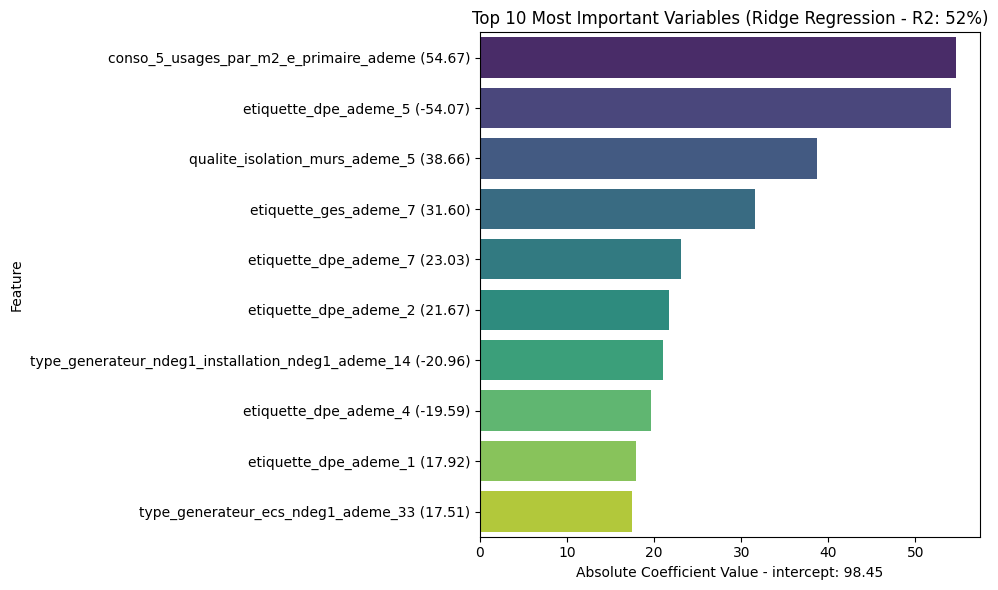

In [78]:
import seaborn as sns

model = model_ridge
# Extract feature names and coefficients
feature_names = model.named_steps['re_encoding'].get_feature_names_out()
coefficients = model.named_steps['model'].coef_

# Add sign indicator to feature names
feature_names_with_sign = [
    f"{feature} (-)" if coef < 0 else f"{feature} (+)"
    for feature, coef in zip(feature_names, coefficients)
]

feature_names_with_coef = [
    f"{feature} ({coef:.2f})" 
    for feature, coef in zip(feature_names, coefficients)
]

# Create a DataFrame for coefficients
coef_df = pd.DataFrame({'Feature': feature_names_with_coef, 'Coefficient': coefficients})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

# Sort by absolute coefficient values
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

# Plot the top 10 most important variables
plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df.head(10), x='Abs_Coefficient', y='Feature', palette='viridis')
plt.title(f'Top 10 Most Important Variables (Ridge Regression - R2: {100*ridge_best_r2:.0f}%)')
plt.xlabel(f'Absolute Coefficient Value - intercept: {ridge_intercept:.2f}')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../ressources/models_fitted/regressions_lineaires/ridge_top_10_features.png', dpi=300)
plt.show()

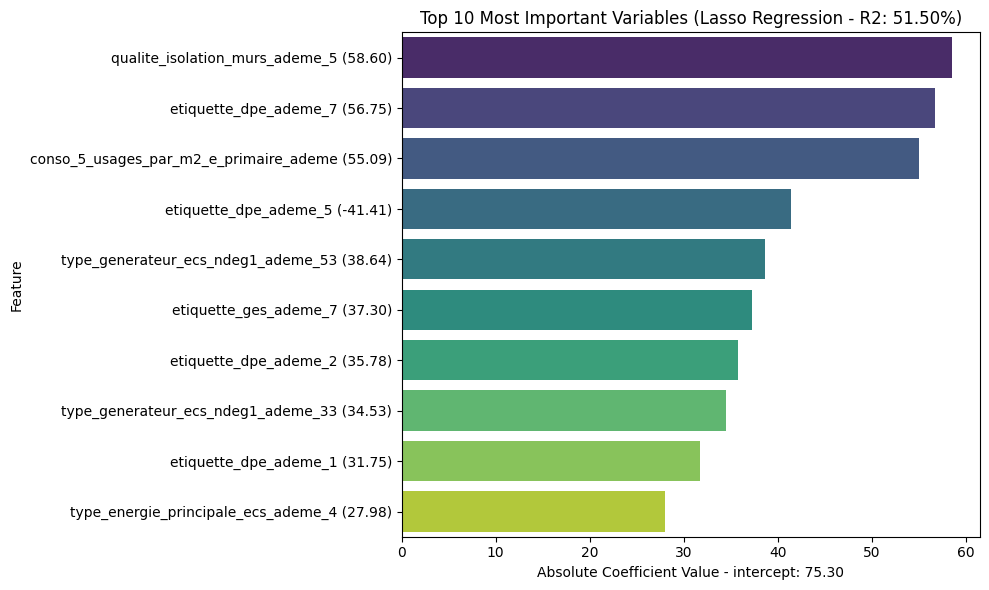

In [79]:
import seaborn as sns

model = model_lasso
# Extract feature names and coefficients
feature_names = model.named_steps['re_encoding'].get_feature_names_out()
coefficients = model.named_steps['model'].coef_

# Add sign indicator to feature names
feature_names_with_sign = [
    f"{feature} (-)" if coef < 0 else f"{feature} (+)"
    for feature, coef in zip(feature_names, coefficients)
]

feature_names_with_coef = [
    f"{feature} ({coef:.2f})" 
    for feature, coef in zip(feature_names, coefficients)
]

# Create a DataFrame for coefficients
coef_df = pd.DataFrame({'Feature': feature_names_with_coef, 'Coefficient': coefficients})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

# Sort by absolute coefficient values
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

# Plot the top 10 most important variables
plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df.head(10), x='Abs_Coefficient', y='Feature', palette='viridis')
plt.title(f'Top 10 Most Important Variables (Lasso Regression - R2: {100*lasso_best_r2:.2f}%)')
plt.xlabel(f'Absolute Coefficient Value - intercept: {lasso_intercept:.2f}')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../ressources/models_fitted/regressions_lineaires/lasso_top_10_features.png', dpi=300)
plt.show()

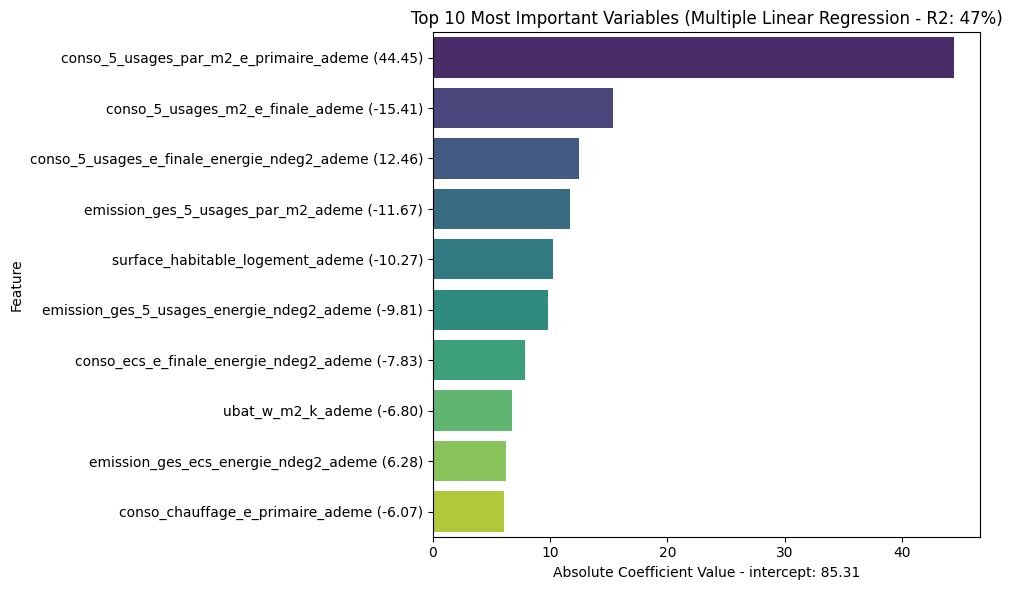

In [80]:
import seaborn as sns

model = model_simple
# Extract feature names and coefficients
feature_names = model.named_steps['re_encoding'].get_feature_names_out()
coefficients = model.named_steps['model'].coef_

# Add sign indicator to feature names
feature_names_with_sign = [
    f"{feature} (-)" if coef < 0 else f"{feature} (+)"
    for feature, coef in zip(feature_names, coefficients)
]

feature_names_with_coef = [
    f"{feature} ({coef:.2f})" 
    for feature, coef in zip(feature_names, coefficients)
]

# Create a DataFrame for coefficients
coef_df = pd.DataFrame({'Feature': feature_names_with_coef, 'Coefficient': coefficients})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

# Sort by absolute coefficient values
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

# Plot the top 10 most important variables
plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df.head(10), x='Abs_Coefficient', y='Feature', palette='viridis')
plt.title(f'Top 10 Most Important Variables (Multiple Linear Regression - R2: {100*simple_best_r2:.0f}%)')
plt.xlabel(f'Absolute Coefficient Value - intercept: {simple_intercept:.2f}')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../ressources/models_fitted/regressions_lineaires/simple_top_10_features.png', dpi=300)
plt.show()